# Lab 5

In [166]:
### MATPLOTLIB SETUP ###
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
from scipy.integrate import cumulative_trapezoid
pd.set_option('display.float_format', lambda x: '%e' % x)

## Amit's library with some utility functions for reading and processing scope data; reproduced below
sys.path.append("../../")
from lib import *

from rich.console import Console
from rich.syntax import Syntax
Console().print(Syntax.from_path("../../lib.py", line_numbers=True, theme="monokai"))

## Jupyter magic
%matplotlib
%matplotlib ipympl
%load_ext autoreload
%autoreload 2

   1 import csv                                                                                                    
   2 import pandas as pd                                                                                           
   3 import numpy as np                                                                                            
   4                                                                                                               
   5 R = 5 # Load Resistance                                                                                       
   6 VG = 18 # Input Voltage                                                                                       
   7 Fs = 50500 # Measured frequency                                                                               
   8 Ts = 1/ Fs                                                                                                    
   9 R_SHUNT = 0.05 # from schematic                                                                               
  10                                                                                                               
  11 # read funky Rigol CSV format                                                                                 
  12 def read_rigol_csv(csv_file_name):                                                                            
  13     with open(csv_file_name) as f:                                                                            
  14         rows = list(csv.reader(f))                                                                            
  15         i = 0                                                                                                 
  16         while rows[0][i] != "":                                                                               
  17             i = i+1                                                                                           
  18         numcols = i-2                                                                                         
  19         t0 = float(rows[1][numcols])                                                                          
  20         dT = float(rows[1][numcols+1])                                                                        
  21                                                                                                               
  22     data = pd.read_csv(csv_file_name, usecols=range(0,numcols), skiprows=[1])                                 
  23     data['X'] = t0+data['X']*dT                                                                               
  24     return data, t0, dT                                                                                       
  25                                                                                                               
  26 def import_and_clean(name, cols, filt, filt_len=10):                                                          
  27     """                                                                                                       
  28     Import and clean some data from the Rigol scope                                                           
  29                                                                                                               
  30     @param name: name of csv file (assumed to live in `./data`)                                               
  31     @param cols: what to rename columns to                                                                    
  32     @param filt: whether to apply 10 sample rolling mean LPF                                                  
  33                                                                                                               
  34     @return pd.df - renamed/filtered dataframe                                             

Using matplotlib backend: ipympl
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Prelab

### Creating digital twin

I first modified my buck converter circuit into a flyback converter by replacing the inductor with a transformer, and adjusting the wiring to match the hardware confugration like so. I chose to represent the magnetizing inductance L inside of the transformer, and set the turns ratio to the variable a.

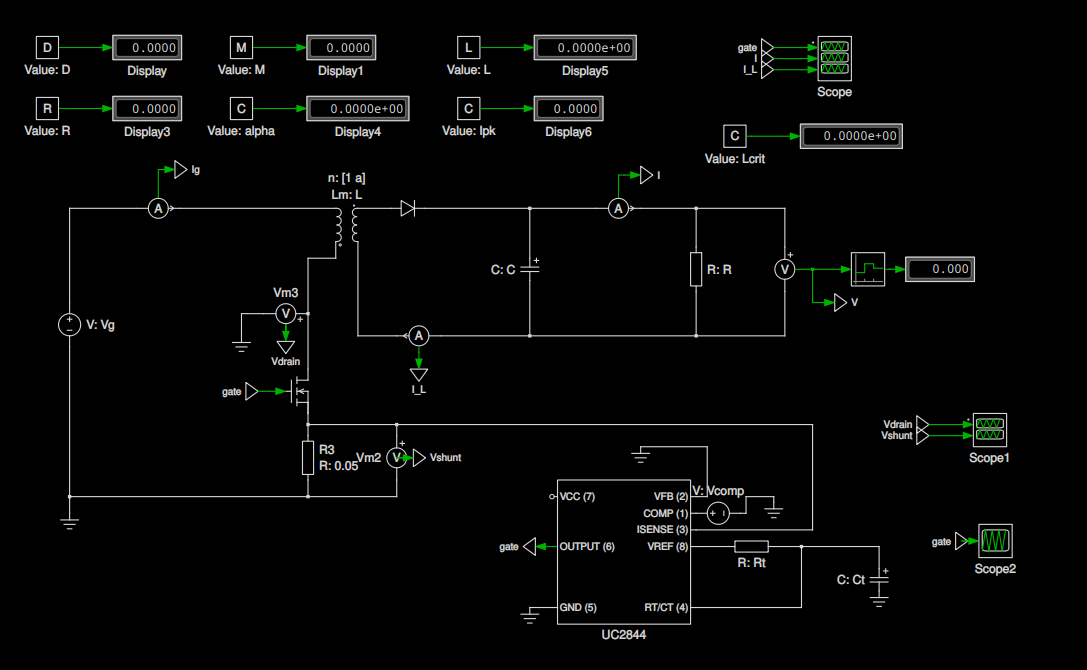

Additionally, I also set up my constant parameters like so (some from the prelab, some from the circuit)

```matlab
Rt = 7.87e3;
Ct = 2.2e-9;
Ts=2.0617e-5; % measured in scope
fs=1/Ts;

D = 0.35;
C=60e-6;
Vg=18;
Vo=10;
R=5;
alpha = 0.7
```

### Calculating L and Ipk

Based on the buck-boost equation from the lectures, I calculated Lcrit like so

$$
L_{crit} = (\frac{1}{M+1})^2 * (\frac{R}{a^2}) * (\frac{T_s}{2})
$$

Note that M is $\frac{V_o}{a*V_g}$, and $R$ is divided by $a^2$ to match the buck boost configuration.

With $L_{crit}$ in hand, we can multiply it by $\alpha$ to find our final L value. This was done with the following setup script code

```matlab
Lcrit = (1/(M+1))^2 * (R/a^2) * (Ts/2)
L = Lcrit * alpha
```

and yielded an inductance of $20.45 uH$

For Ipk, I used the Ipk DCM equation from the lecture notes

$$
I_{pk} = \frac{2}{\sqrt{\alpha}} * (M+1) * (\frac{V_i}{R_i})
$$

where $V_i$ and $R_i$ are the voltage on the left side of the transformer and equivalent resistance $R_i = \frac{R}{a^2}$ (by the buck boost converter transform).

This yielded an $I_{pk}$ of 6.35 amps

### Verifying calculations

Entering these calculations into my PLECS sim (and adjusting my frequency to match the one I measured earlier on the PLECS scope) output a voltage of 10.0002 V, which is very (surprisingly, in fact) accurate.

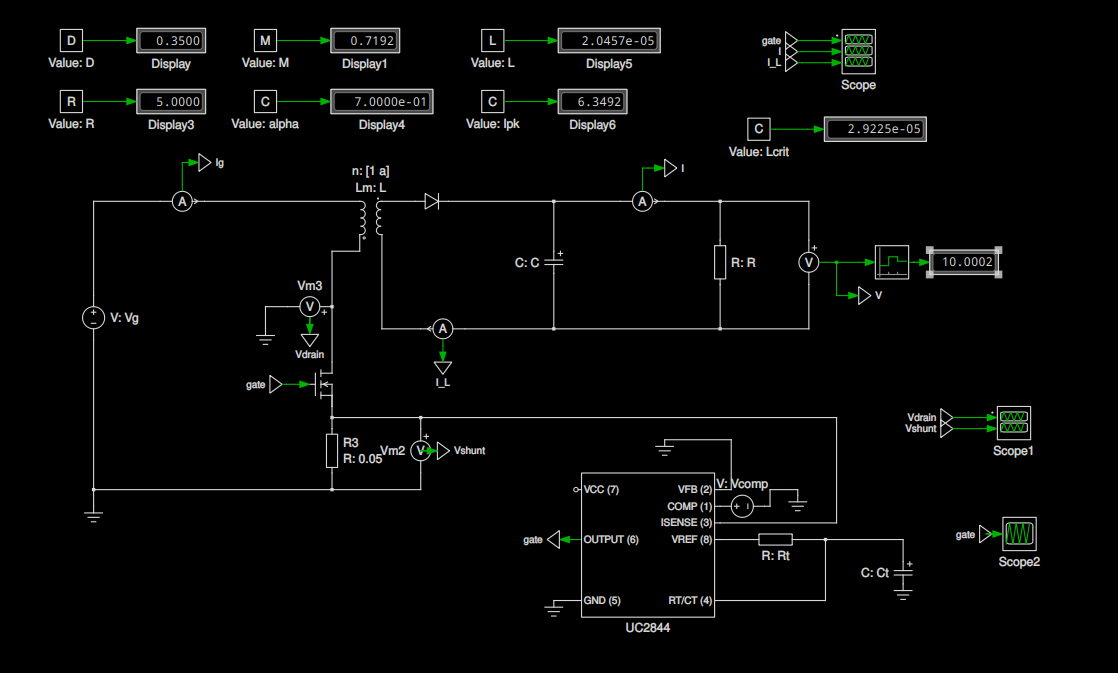

# Lab

### Q1

We are using transformer number 11

### Q2

See Q7 below for the measured shunt and drain voltage plots

### Q3/Q4

The measured current draw from the power supply and output voltage is as follows

4.06 V output - 0.29 A

7.02 V output - 0.79 A

9.02 V output - 1.28 A

### Q5

The code cell below plots our two measurements (Vinj- and Vdd) from task 2

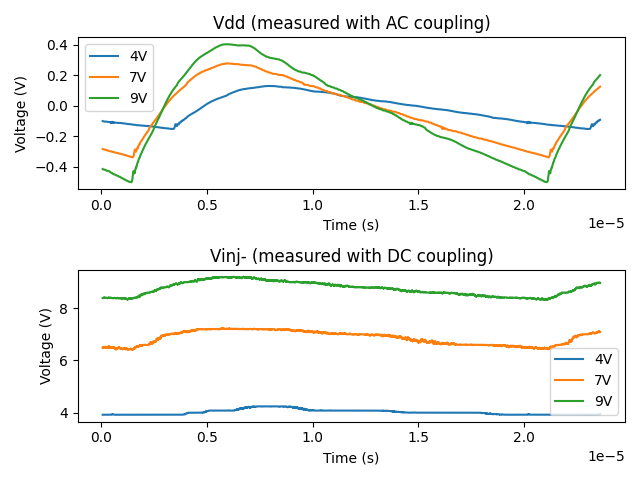

In [167]:
names = ['4', '7', '9']

figure, (ax1, ax2) = plt.subplots(2,1)
for name, t, V in zip(names, ts, Vs):
    df, _ = import_and_clean(f't2_{name}v', ["Vdd", "Vinj"], True, 30) # LPF to smooth out spikes and make data easier to inspect
    df = df[df['X'] < 2.36e-5]
    df.plot(x="X", y="Vdd", ax=ax1, title="Vdd (measured with AC coupling)")
    df.plot(x="X", y="Vinj", ax=ax2, title="Vinj- (measured with DC coupling)")

ax1.legend(["4V", "7V", "9V"])
ax2.legend(["4V", "7V", "9V"])
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Voltage (V)")
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Voltage (V)")
figure.tight_layout()

### Q6

Our output voltages for task 2 are as follows:

| Nominal Output | Measured Output |
| -------------- | --------------- |
| 4 V            | 4.16 V          |
| 7 V            | 7.1 V           |
| 9 V            | 9.06 V          |

# Post lab analysis

### Q7 

The following code cell calculates the magnetizing inductance of our circuit at each of our 3 voltage levels. There's a decent amount of variation between these values, but given our highly imperfect lab setup, I'm inclined to believe that these are in the correct ballpark.

Magnetizing inductance at output voltage of 4V: 14.565 uH
Magnetizing inductance at output voltage of 7V: 14.815 uH
Magnetizing inductance at output voltage of 9V: 15.114 uH
Mean Inductance: 14.832 uH


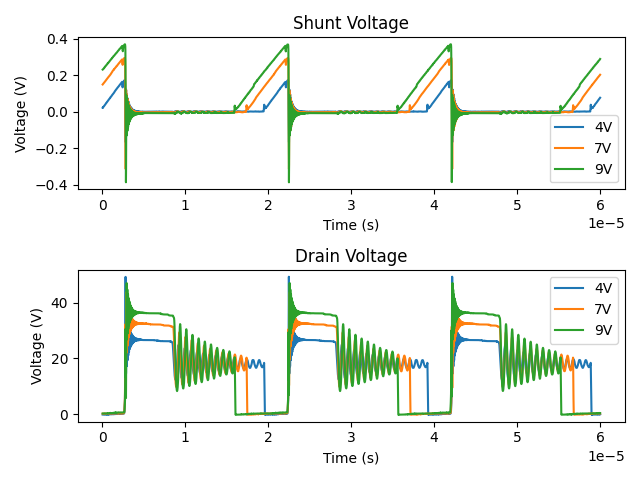

In [168]:
names = ['4', '7', '9']
a = 0.4862 # transformer turns ratio
ts = [(2e-5, 2.15e-5), (1.8e-5, 2.15e-5), (1.7e-5, 2.15e-5)]
Vs = [4.06, 7.02, 9.02]
Ls = []

figure, (ax1, ax2) = plt.subplots(2,1)
for name, t, V in zip(names, ts, Vs):
    df, _ = import_and_clean(f't1_{name}v', ["Vshunt", "Vdrain"], True, 30) # LPF to smooth out spikes and make data easier to inspect
    df.plot(x="X", y="Vshunt", ax=ax1, title="Shunt Voltage")
    df.plot(x="X", y="Vdrain", ax=ax2, title="Drain Voltage")
    # change to library - I now am passing in V_L of the magnetizing inductance, which should roughly be Vg (minus FET and shunt drops)
    Ls.append(L := calc_inductance(df, *t, VG)) 
    print(f"Magnetizing inductance at output voltage of {name}V: {round(L * 10e5, 3)} uH")

ax1.legend(["4V", "7V", "9V"])
ax2.legend(["4V", "7V", "9V"])
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Voltage (V)")
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Voltage (V)")
figure.tight_layout()
print(f"Mean Inductance: {round((Lmean := np.mean(Ls)) * 10e5, 3)} uH")

### Q8

To calculate the turns ratio, I first made note of the drain voltage when the FET is off and the diode is on (so the right side of the circuit is running) for each voltage level. These were about 26.6 V, 32.3 V, and 36.2 V for 4V, 7V and 9V output respectively.

Looking at the circuit diagram for the flyback converter, when the FET is off, the output of the circuit is being driven by the capacitor, so the right side of the transformer has the output voltage across it. This is being reflected on the left side of the transformer (divided by the turns ratio). 

The FET drain voltage then becomes this reflected voltage plus the input voltage. So to find the turns ratio, we first subtract out the input voltage to give us the left side of the transformer's voltage, then divide the output voltage by it to find the turns ratio of the transformer. This calculation is performed in the code cell below for each test run, and then averaged.

In [169]:
drains = [26.6, 32.3, 36.2]
turn_ratios = []

for n, drain, V in zip(names, drains, Vs):
    turn_ratios.append(a := (V / (drain - VG)))
    print(f"Transformer turn ratio at output voltage {n}V is {round(a, 4)}")

print(f"Mean Turns Ratio: {round(np.mean(turn_ratios), 4)}")

Transformer turn ratio at output voltage 4V is 0.4721
Transformer turn ratio at output voltage 7V is 0.4909
Transformer turn ratio at output voltage 9V is 0.4956
Mean Turns Ratio: 0.4862


### Q9

I adjusted my digital twin as follows.

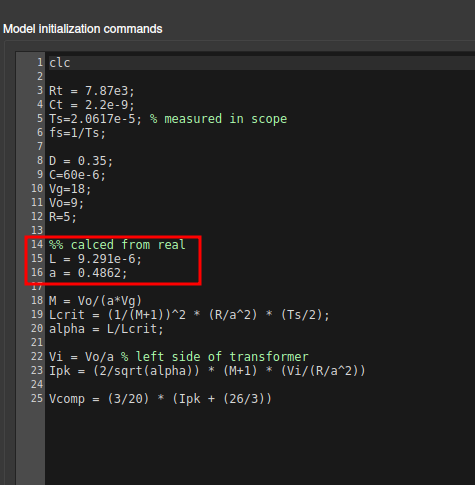

### Q10

By simulating with an output of 4V, 7V, and 9V, I generated the following plots as counterparts to our experimental data, and the simulated output voltages are listed below.

| Nominal Output | Measured Output |
| -------------- | --------------- |
| 4 V            | 4.07 V          |
| 7 V            | 7.11 V           |
| 9 V            | 9.07 V          |

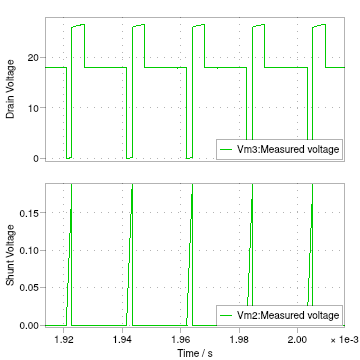
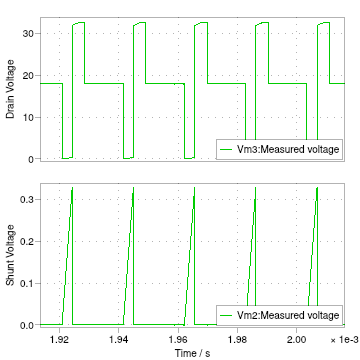
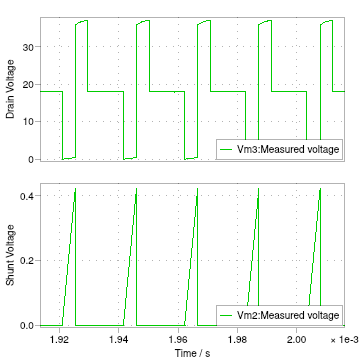

Overall, the plots share relatively similar characteristic to the real counterparts. The shunt voltage (and current) increases as the first transformer winding charges, then drops to 0 when the FET closes (albeit with a high frequency oscillation in the real graph when the FET switches off) The amplitudes are similar, although it does seem like the simulated shunt voltages do reach slightly higher in amplitude than the real ones (20-50 mV, roughly). Both graphs operate near 50 kHZ as well, which matches what the output from the UC2844 chip should be.

On the drain side, both the real and simluated graphs show 3 distinct modes of operation, with the drain voltage at its lowest (near 0) value when the FET is on (and the primary winding is being charged), then its highest value when the FET is off, but the diode is on and the winding is being discharged on the output side of the circuit (equal to the supply voltage plus the transformed output, as described above), and lastly an intermediate value (equal to the supply voltage) when the FET and diode are both off. The amplitudes of these levels are fairly similar to the real graphs, but there are also EMI spikes on FET switches and some sinusoidal ripple in our real sample (very high frequency oscillations in the drain when the FET first switches off, and much lower frequency when the diode turns off as well), due to resonance with parasitic capacitances/leakage inductances in our circuit. Both of these graphs also run right around 50 kHz.

13.75% 22.84% 21.73%
3.4453A 5.904A 7.408A


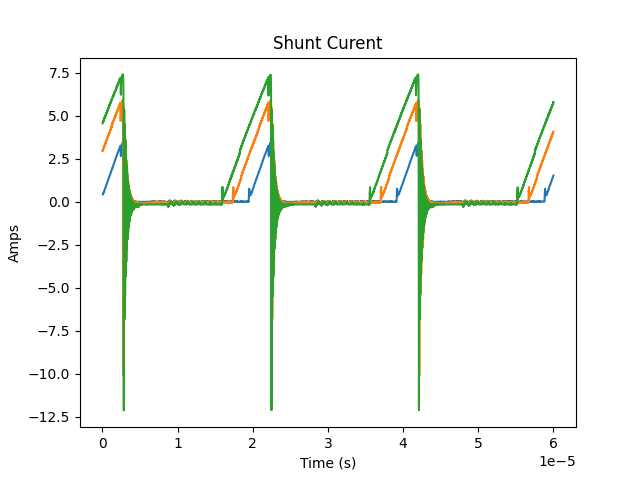

In [170]:
v4, _ = import_and_clean(f't1_4v', ["Vshunt", "Vdrain"], True, 30)
v7, _ = import_and_clean(f't1_7v', ["Vshunt", "Vdrain"], True)
v9, _ = import_and_clean(f't1_9v', ["Vshunt", "Vdrain"], True)
Ipks = []

# plot current
fig, ax = plt.subplots()
for data in [v4, v7, v9]:
    data['I_calc'] = data['Vshunt'] / 0.05
    data.plot(x="X", y="I_calc", legend=False, title=f"Shunt Curent", xlabel="Time (s)", ylabel="Amps", ax=ax)
    Ipks.append(max(data["I_calc"].dropna()))

# calculate duty cycle
print(*[f"{round(duty_cycle(x, 'Vdrain', 1.4e-5, 2.4e-5) * 100, 2)}%" for x in [v4, v7, v9]])
print(*[f"{round(x, 4)}A" for x in Ipks])

The table below shows our real-life measured duty cycle and peak current, as well as their theoretical predictions. The real Ipk was found by inspecting the shunt voltage and applying Ohm's law with the shunt resistance (plots above), and the real duty cycle was calcualted by looking at the time the drain voltage was low (code cell above).

The simulated duty cycle found by inspecting the gate voltage waveform (example screengrab attached from 4V test), and the theoretical Ipk was calculated like so

$$I_{pk} = \frac{2}{\sqrt{\alpha}} * (M+1) * \frac{V_i}{R/a^2}$$

where $V_i$ refers to the voltage on the left side of the transformer (that is, $\frac{V_{out}}{a}$)

| Output Voltage | Real D | Predicted D | Real Ipk (A) | Predicted Ipk (A) |
|----------------|--------|-------------|--------------|-------------------|
| 4V             | 13.89% | 12.15%      | 3.45         | 3.027             |
| 7V             | 23.97% | 20.96%      | 5.904        | 5.290             |
| 9V             | 25.46% | 27.20%      | 7.408        | 6.756             |


Note that the listed output voltages in the table are nominally what the task requested, but I ran the simulations at the precise output voltage we measured on our real hardware to try and be as consistent as possible

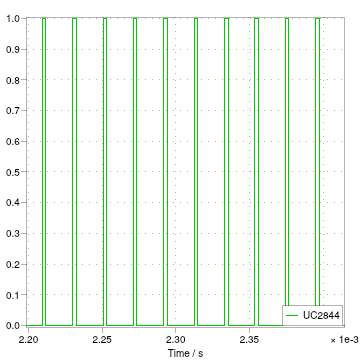

These results are relatively close, at least, the duty cycles is within 2-3 percent or so - but interestingly not as close as they were when I compared these same parameters from our buck simulation. The peak current is considerably further off - somewhere between 500-700 milliamps, which is quite a large deviation; large enough that I'm suspecting I may have made a calculation error somewhere. That said, my simulation does provide an output voltage within 15 mV of what I specify as the desired output, and I haven't changed my Vcomp equation, so that would lead me to believe that in a peak current controlled converter, the peak current is correct.


I have some other ideas as to why this might be - imperfect modeling of Vcomp/the UC2844 chip in general, imperfect components in the real circuit, measurement error of parameters like switching frequency - but I don't have a great intuition of which of these plays the biggest part.


### Q11

To find the output capacitance, I used the $I = C \frac{dV}{dt}$ equation of a capacitor.

To find the current, I mainly applied KCL a few times - I first found the current going through the inductor by integrating the voltage through the inductor (approximated as input voltage minus drain voltage while the FET is on) divided by the magnetizing inductance per the inductor equation $V = L \frac{dI}{dt}$. I then subtracted this from the input current (that was being drawn from the power supply) and multiplied by $1/\alpha$ to find the current that was being transferred to the right side of the transformer. Lastly, I subtracted the output current through the load ($\frac{V_{out}}{R}$), such that any remaining current must go through the capacitors.

I found $\frac{dV}{dt}$ by running a linear regression fit on the linear section of the Vdd graph (measured with AC coupling), then divided the current by this value to find the capacitance. This calculation and the results at all three voltages are in the below code cell. Looking at the hardware schematic, I see 4 22uF capacitors there, so I'd expect the value to be around 88uF, however my calculation is around 3 times that. I'm almost certain this is due to some form of calculation error on my part, or using the incorrect data/slice of data; while there may be some smaller measurement error, I'd be very surprised if it's this large. I'm reasonably confident in my methodology, but worked up the last minute trying to look for bugs and was unable to fix the problem.

Calculated capacitance for 4V output: 0.000319 uF
Calculated capacitance for 7V output: 0.000261 uF
Calculated capacitance for 9V output: 0.000219 uF
Mean capacitance: 0.000266 uF


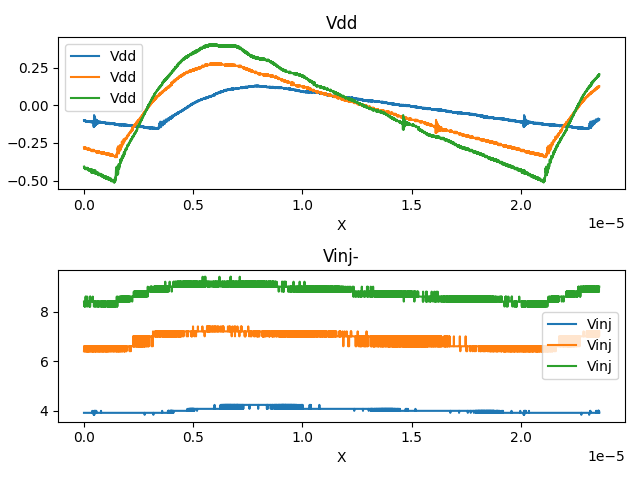

In [171]:
spans = [(1e-5, 2e-5), (0.8e-5, 2e-5), (0.8e-5, 2e-5)]
dspans = [(1.97e-5, 2.22e-5), (1.75e-5, 2.22e-5), (1.61e-5, 2.22e-5)]
Vouts = [4.16, 7.1, 9.06]
currents_in = [0.31, 0.81, 1.28]
Cs = []

fig, (a1, a2) = plt.subplots(2, 1)

for i, (n, span, dspan, Vout, I_in) in enumerate(zip(names, spans, dspans, Vouts, currents_in)):
    sd, _ = import_and_clean(f"t1_{n}v", ['Vshunt', 'Vdrain'], False)
    df, _ = import_and_clean(f"t2_{n}v", ['Vdd', 'Vinj'], False)
    df = df[df['X'] < 2.36e-5]
    df.plot(x="X", y="Vdd", ax=a1, title="Vdd")
    df.plot(x="X", y="Vinj", ax=a2, title="Vinj-")

    # calc dV
    start, end = span
    rng = np.where((df["X"] > start) & (df["X"] < end))[0]
    dV = abs(np.polyfit(df["X"][rng[0]:rng[-1]], df['Vdd'][rng[0]:rng[-1]], 1)[0])

    # calc I
    rng = np.where((sd["X"] > dspan[0]) & (sd["X"] < dspan[1]))[0]
    I_L = cumulative_trapezoid((VG - sd["Vdrain"][rng[0]:rng[-1]])/Ls[i], sd["X"][rng[0]:rng[-1]].fillna(0))[-1] # integrate w respect to time; dI = V/L
    I_secondary = (1/a) * (I_in - I_L) # current going to secondary side of transformer
    I_out = Vout/R # current through load resistor
    I_cap = abs(I_secondary - I_out) # remaining current goes through output caps

    # calc C
    Cs.append(c := I_cap / dV)
    print(f"Calculated capacitance for {n}V output: {round(c, 6)} uF")

fig.tight_layout()
ax1.legend(["4V", "7V", "9V"])
ax2.legend(["4V", "7V", "9V"])
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Voltage (V)")
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Voltage (V)")

print(f"Mean capacitance: {round(np.mean(Cs), 6)} uF")